In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# import os

# # This lists every file the Colab server can currently see
# print(os.listdir('/content/drive/MyDrive/Colab Notebooks'))

['Plant Species Image_Classification.ipynb', 'download-image.ipynb', 'Fashion-MNIST-Image-Classification.ipynb', 'Untitled0.ipynb', 'Data_train.csv', 'Test_set.csv', 'flight_xgb.pkl']


In [420]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [421]:
train_data = pd.read_csv("fbs-vue/Data_train.csv")

In [422]:
pd.set_option('display.max_columns', None)

In [ ]:
train_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,Philippine Airlines,2024-01-05,Manila (MNL),Cebu (CEB),MNL-CEB,08:15,09:45,1h 30m,0,No info,4500
1,Cebu Pacific,2024-01-08,Manila (MNL),Davao (DVO),MNL-DVO,06:30,08:45,2h 15m,0,No info,5200
2,AirAsia Philippines,2024-01-12,Cebu (CEB),Puerto Princesa (PPS),CEB-PPS,11:20,12:50,1h 30m,0,No info,3800
3,Philippine Airlines,2024-01-15,Manila (MNL),Iloilo (ILO),MNL-ILO,14:45,16:00,1h 15m,0,No info,4200
4,Cebu Pacific,2024-01-18,Davao (DVO),Cagayan de Oro (CGY),DVO-CGY,09:30,10:15,0h 45m,0,No info,3200


In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          1186 non-null   object
 1   Date_of_Journey  1186 non-null   object
 2   Source           1186 non-null   object
 3   Destination      1186 non-null   object
 4   Route            1186 non-null   object
 5   Dep_Time         1186 non-null   object
 6   Arrival_Time     1186 non-null   object
 7   Duration         1186 non-null   object
 8   Total_Stops      1186 non-null   object
 9   Additional_Info  1186 non-null   object
 10  Price            1186 non-null   object
dtypes: object(11)
memory usage: 102.1+ KB


In [ ]:
train_data["Duration"].value_counts()


,count
Duration,
1h 15m,234
1h 30m,227
2h 15m,109
0h 45m,85
1h 00m,66
4h 15m,60
1h 20m,51
1h 50m,50
6h 15m,48


In [426]:

train_data.dropna(inplace = True)

In [ ]:

train_data.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [428]:
train_data["Date_of_Journey"] = pd.to_datetime(train_data["Date_of_Journey"], errors='coerce')
train_data = train_data.dropna(subset=["Date_of_Journey"])


In [429]:
train_data["Journey_day"] = train_data["Date_of_Journey"].dt.day

In [430]:
train_data["Journey_month"] = pd.to_datetime(train_data["Date_of_Journey"], format = "%d/%m/%Y").dt.month


In [ ]:
train_data.head()


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month
0,Philippine Airlines,2024-01-05,Manila (MNL),Cebu (CEB),MNL-CEB,08:15,09:45,1h 30m,0,No info,4500,5,1
1,Cebu Pacific,2024-01-08,Manila (MNL),Davao (DVO),MNL-DVO,06:30,08:45,2h 15m,0,No info,5200,8,1
2,AirAsia Philippines,2024-01-12,Cebu (CEB),Puerto Princesa (PPS),CEB-PPS,11:20,12:50,1h 30m,0,No info,3800,12,1
3,Philippine Airlines,2024-01-15,Manila (MNL),Iloilo (ILO),MNL-ILO,14:45,16:00,1h 15m,0,No info,4200,15,1
4,Cebu Pacific,2024-01-18,Davao (DVO),Cagayan de Oro (CGY),DVO-CGY,09:30,10:15,0h 45m,0,No info,3200,18,1


In [432]:
train_data.drop(["Date_of_Journey"], axis = 1, inplace = True)


In [ ]:

train_data.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month
0,Philippine Airlines,Manila (MNL),Cebu (CEB),MNL-CEB,08:15,09:45,1h 30m,0,No info,4500,5,1
1,Cebu Pacific,Manila (MNL),Davao (DVO),MNL-DVO,06:30,08:45,2h 15m,0,No info,5200,8,1
2,AirAsia Philippines,Cebu (CEB),Puerto Princesa (PPS),CEB-PPS,11:20,12:50,1h 30m,0,No info,3800,12,1
3,Philippine Airlines,Manila (MNL),Iloilo (ILO),MNL-ILO,14:45,16:00,1h 15m,0,No info,4200,15,1
4,Cebu Pacific,Davao (DVO),Cagayan de Oro (CGY),DVO-CGY,09:30,10:15,0h 45m,0,No info,3200,18,1


In [434]:
# Convert to datetime once, specifying the format
# %H is for 24-hour clock, %M is for minutes
train_data["Dep_Time"] = pd.to_datetime(train_data["Dep_Time"], format="%H:%M")

# Extracting Hours
train_data["Dep_hour"] = train_data["Dep_Time"].dt.hour

# Extracting Minutes
train_data["Dep_min"] = train_data["Dep_Time"].dt.minute

# Drop the original column
train_data.drop(["Dep_Time"], axis = 1, inplace = True)

In [ ]:
train_data.head()

,Airline,Source,Destination,Route,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min
0,Philippine Airlines,Manila (MNL),Cebu (CEB),MNL-CEB,09:45,1h 30m,0,No info,4500,5,1,8,15
1,Cebu Pacific,Manila (MNL),Davao (DVO),MNL-DVO,08:45,2h 15m,0,No info,5200,8,1,6,30
2,AirAsia Philippines,Cebu (CEB),Puerto Princesa (PPS),CEB-PPS,12:50,1h 30m,0,No info,3800,12,1,11,20
3,Philippine Airlines,Manila (MNL),Iloilo (ILO),MNL-ILO,16:00,1h 15m,0,No info,4200,15,1,14,45
4,Cebu Pacific,Davao (DVO),Cagayan de Oro (CGY),DVO-CGY,10:15,0h 45m,0,No info,3200,18,1,9,30


In [436]:
# Convert Arrival_Time to datetime once
# If it's just HH:MM, use format="%H:%M"
# If it has extra info, use errors='coerce' or a specific format
train_data["Arrival_Time"] = pd.to_datetime(train_data["Arrival_Time"], format="%H:%M")

# Extracting Hours
train_data["Arrival_hour"] = train_data["Arrival_Time"].dt.hour

# Extracting Minutes
train_data["Arrival_min"] = train_data["Arrival_Time"].dt.minute

# Drop the original column
train_data.drop(["Arrival_Time"], axis = 1, inplace = True)

In [ ]:
train_data.head()

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min
0,Philippine Airlines,Manila (MNL),Cebu (CEB),MNL-CEB,1h 30m,0,No info,4500,5,1,8,15,9,45
1,Cebu Pacific,Manila (MNL),Davao (DVO),MNL-DVO,2h 15m,0,No info,5200,8,1,6,30,8,45
2,AirAsia Philippines,Cebu (CEB),Puerto Princesa (PPS),CEB-PPS,1h 30m,0,No info,3800,12,1,11,20,12,50
3,Philippine Airlines,Manila (MNL),Iloilo (ILO),MNL-ILO,1h 15m,0,No info,4200,15,1,14,45,16,0
4,Cebu Pacific,Davao (DVO),Cagayan de Oro (CGY),DVO-CGY,0h 45m,0,No info,3200,18,1,9,30,10,15


In [438]:
# Time taken by plane to reach destination is called Duration
# It is the differnce betwwen Departure Time and Arrival time


# Assigning and converting Duration column into list
duration = list(train_data["Duration"])

for i in range(len(duration)):
    if len(duration[i].split()) != 2:    # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        else:
            duration[i] = "0h " + duration[i]           # Adds 0 hour

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    duration_hours.append(int(duration[i].split(sep = "h")[0]))    # Extract hours from duration
    duration_mins.append(int(duration[i].split(sep = "m")[0].split()[-1]))   # Extracts only minutes from duration

In [439]:
# Adding duration_hours and duration_mins list to train_data dataframe

train_data["Duration_hours"] = duration_hours
train_data["Duration_mins"] = duration_mins

In [440]:
train_data.drop(["Duration"], axis = 1, inplace = True)


In [ ]:
train_data.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,Philippine Airlines,Manila (MNL),Cebu (CEB),MNL-CEB,0,No info,4500,5,1,8,15,9,45,1,30
1,Cebu Pacific,Manila (MNL),Davao (DVO),MNL-DVO,0,No info,5200,8,1,6,30,8,45,2,15
2,AirAsia Philippines,Cebu (CEB),Puerto Princesa (PPS),CEB-PPS,0,No info,3800,12,1,11,20,12,50,1,30
3,Philippine Airlines,Manila (MNL),Iloilo (ILO),MNL-ILO,0,No info,4200,15,1,14,45,16,0,1,15
4,Cebu Pacific,Davao (DVO),Cagayan de Oro (CGY),DVO-CGY,0,No info,3200,18,1,9,30,10,15,0,45


In [ ]:
train_data["Airline"].value_counts()

,count
Airline,
Philippine Airlines,394
Cebu Pacific,392
AirAsia Philippines,388


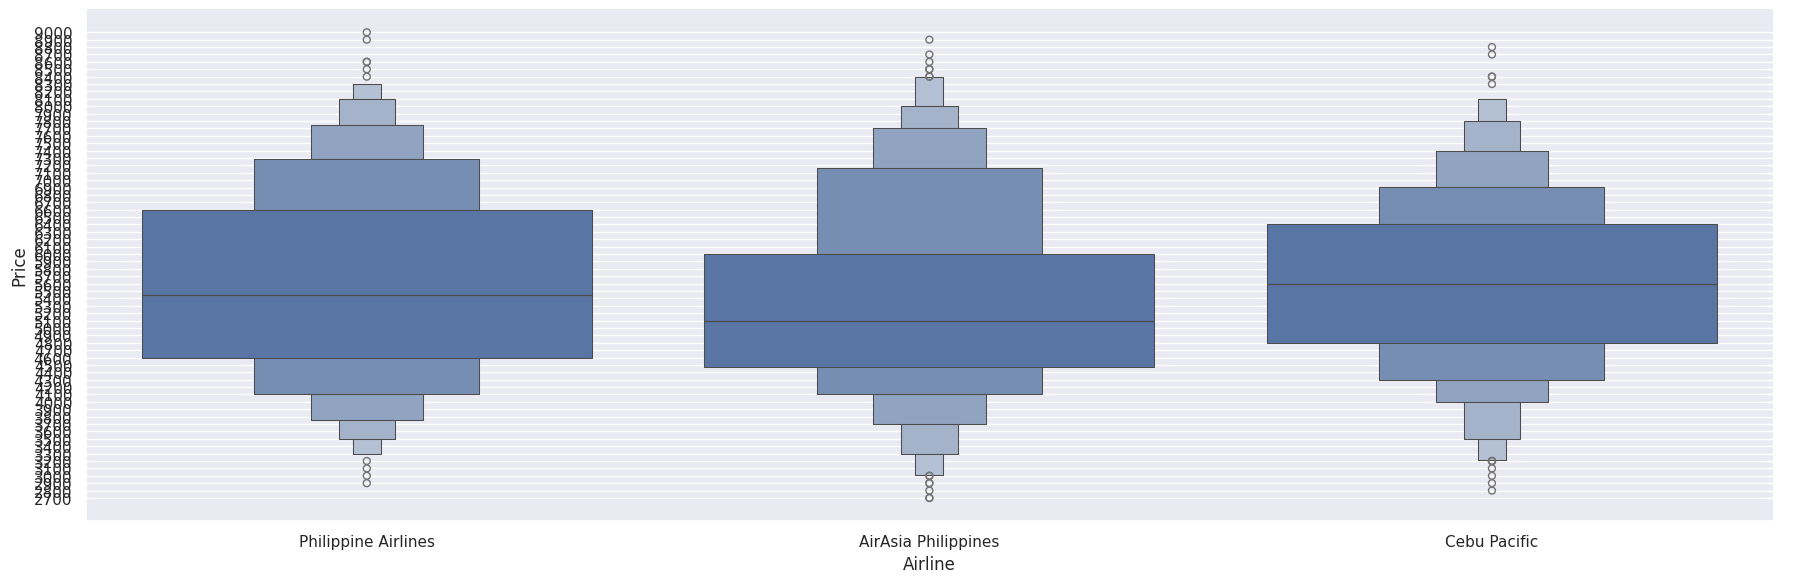

In [ ]:
# From graph we can see that Jet Airways Business have the highest Price.
# Apart from the first Airline almost all are having similar median

# Airline vs Price
sns.catplot(y = "Price", x = "Airline", data = train_data.sort_values("Price", ascending = False), kind="boxen", height = 6, aspect = 3)
plt.show()

In [ ]:
# As Airline is Nominal Categorical data we will perform OneHotEncoding

Airline = train_data[["Airline"]]

Airline = pd.get_dummies(Airline).astype(int)

Airline.head()

,Airline_AirAsia Philippines,Airline_Cebu Pacific,Airline_Philippine Airlines
0,0,0,1
1,0,1,0
2,1,0,0
3,0,0,1
4,0,1,0


In [ ]:
train_data["Source"].value_counts()

,count
Source,
Manila (MNL),615
Davao (DVO),125
Cebu (CEB),122
Zamboanga (ZAM),48
Bacolod (BCD),47
Legazpi (LGP),36
Tacloban (TAC),36
Puerto Princesa (PPS),36
Iloilo (ILO),25


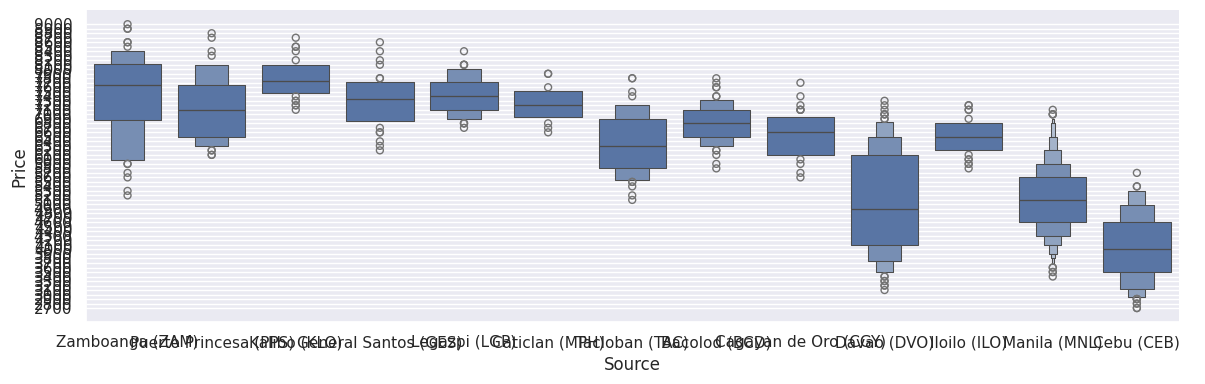

In [ ]:
# Source vs Price

sns.catplot(y = "Price", x = "Source", data = train_data.sort_values("Price", ascending = False), kind="boxen", height = 4, aspect = 3)
plt.show()

In [ ]:
# As Source is Nominal Categorical data we will perform OneHotEncoding

Source = train_data[["Source"]]

Source = pd.get_dummies(Source).astype(int)

Source.head()

,Source_Bacolod (BCD),Source_Cagayan de Oro (CGY),Source_Caticlan (MPH),Source_Cebu (CEB),Source_Davao (DVO),Source_General Santos (GES),Source_Iloilo (ILO),Source_Kalibo (KLO),Source_Legazpi (LGP),Source_Manila (MNL),Source_Puerto Princesa (PPS),Source_Tacloban (TAC),Source_Zamboanga (ZAM)
0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,0,1,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,0,0


In [ ]:
train_data["Destination"].value_counts()

,count
Destination,
Cebu (CEB),166
Davao (DVO),144
Iloilo (ILO),143
Puerto Princesa (PPS),93
Legazpi (LGP),91
General Santos (GES),86
Kalibo (KLO),76
Cagayan de Oro (CGY),75
Tacloban (TAC),75


In [ ]:
# As Destination is Nominal Categorical data we will perform OneHotEncoding

Destination = train_data[["Destination"]]

Destination = pd.get_dummies(Destination).astype(int)

Destination.head()

,Destination_Bacolod (BCD),Destination_Cagayan de Oro (CGY),Destination_Caticlan (MPH),Destination_Cebu (CEB),Destination_Clark (CRK),Destination_Davao (DVO),Destination_General Santos (GES),Destination_Iloilo (ILO),Destination_Kalibo (KLO),Destination_Legazpi (LGP),Destination_Manila (MNL),Destination_Puerto Princesa (PPS),Destination_Tacloban (TAC),Destination_Zamboanga (ZAM)
0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
train_data["Route"]

,Route
0,MNL-CEB
1,MNL-DVO
2,CEB-PPS
3,MNL-ILO
4,DVO-CGY
...,...
1181,MNL-KLO
1182,MNL-DVO
1183,MNL-CEB
1184,MNL-GES


In [451]:
# Additional_Info contains almost 80% no_info
# Route and Total_Stops are related to each other

train_data.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

In [ ]:
train_data["Total_Stops"].value_counts()

,count
Total_Stops,
0,862
1,312


In [453]:
# As this is case of Ordinal Categorical type we perform LabelEncoder
# Here Values are assigned with corresponding keys

train_data.replace({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}, inplace = True)

In [ ]:
train_data.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins
0,Philippine Airlines,Manila (MNL),Cebu (CEB),0,4500,5,1,8,15,9,45,1,30
1,Cebu Pacific,Manila (MNL),Davao (DVO),0,5200,8,1,6,30,8,45,2,15
2,AirAsia Philippines,Cebu (CEB),Puerto Princesa (PPS),0,3800,12,1,11,20,12,50,1,30
3,Philippine Airlines,Manila (MNL),Iloilo (ILO),0,4200,15,1,14,45,16,0,1,15
4,Cebu Pacific,Davao (DVO),Cagayan de Oro (CGY),0,3200,18,1,9,30,10,15,0,45


In [455]:
# Concatenate dataframe --> train_data + Airline + Source + Destination

data_train = pd.concat([train_data, Airline, Source, Destination], axis = 1)

In [ ]:
data_train.head()

,Airline,Source,Destination,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_AirAsia Philippines,Airline_Cebu Pacific,Airline_Philippine Airlines,Source_Bacolod (BCD),Source_Cagayan de Oro (CGY),Source_Caticlan (MPH),Source_Cebu (CEB),Source_Davao (DVO),Source_General Santos (GES),Source_Iloilo (ILO),Source_Kalibo (KLO),Source_Legazpi (LGP),Source_Manila (MNL),Source_Puerto Princesa (PPS),Source_Tacloban (TAC),Source_Zamboanga (ZAM),Destination_Bacolod (BCD),Destination_Cagayan de Oro (CGY),Destination_Caticlan (MPH),Destination_Cebu (CEB),Destination_Clark (CRK),Destination_Davao (DVO),Destination_General Santos (GES),Destination_Iloilo (ILO),Destination_Kalibo (KLO),Destination_Legazpi (LGP),Destination_Manila (MNL),Destination_Puerto Princesa (PPS),Destination_Tacloban (TAC),Destination_Zamboanga (ZAM)
0,Philippine Airlines,Manila (MNL),Cebu (CEB),0,4500,5,1,8,15,9,45,1,30,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,Cebu Pacific,Manila (MNL),Davao (DVO),0,5200,8,1,6,30,8,45,2,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,AirAsia Philippines,Cebu (CEB),Puerto Princesa (PPS),0,3800,12,1,11,20,12,50,1,30,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,Philippine Airlines,Manila (MNL),Iloilo (ILO),0,4200,15,1,14,45,16,0,1,15,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,Cebu Pacific,Davao (DVO),Cagayan de Oro (CGY),0,3200,18,1,9,30,10,15,0,45,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [457]:
data_train.drop(["Airline", "Source", "Destination"], axis = 1, inplace = True)

In [ ]:
data_train.head()

,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_AirAsia Philippines,Airline_Cebu Pacific,Airline_Philippine Airlines,Source_Bacolod (BCD),Source_Cagayan de Oro (CGY),Source_Caticlan (MPH),Source_Cebu (CEB),Source_Davao (DVO),Source_General Santos (GES),Source_Iloilo (ILO),Source_Kalibo (KLO),Source_Legazpi (LGP),Source_Manila (MNL),Source_Puerto Princesa (PPS),Source_Tacloban (TAC),Source_Zamboanga (ZAM),Destination_Bacolod (BCD),Destination_Cagayan de Oro (CGY),Destination_Caticlan (MPH),Destination_Cebu (CEB),Destination_Clark (CRK),Destination_Davao (DVO),Destination_General Santos (GES),Destination_Iloilo (ILO),Destination_Kalibo (KLO),Destination_Legazpi (LGP),Destination_Manila (MNL),Destination_Puerto Princesa (PPS),Destination_Tacloban (TAC),Destination_Zamboanga (ZAM)
0,0,4500,5,1,8,15,9,45,1,30,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,5200,8,1,6,30,8,45,2,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,3800,12,1,11,20,12,50,1,30,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,4200,15,1,14,45,16,0,1,15,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,3200,18,1,9,30,10,15,0,45,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
data_train.shape

(1174, 40)

In [460]:
test_data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Test_set.csv")

In [ ]:
test_data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info
0,Philippine Airlines,2023-01-01,Manila (MNL),Cebu (CEB),MNL-CEB,8:15,9:45,1h 30m,0,New Year
1,Cebu Pacific,2023-01-01,Manila (MNL),Davao (DVO),MNL-DVO,6:30,8:45,2h 15m,0,New Year
2,AirAsia Philippines,2023-01-01,Manila (MNL),Iloilo (ILO),MNL-ILO,14:45,16:00,1h 15m,0,New Year
3,Philippine Airlines,2023-01-02,Bacolod (BCD),Zamboanga (ZAM),BCD-CEB-ZAM,9:00,12:55,3h 55m,1,Layover in CEB
4,Cebu Pacific,2023-01-02,Manila (MNL),Puerto Princesa (PPS),MNL-PPS,10:10,11:40,1h 30m,0,No info


In [ ]:
test_data = pd.read_csv("fbs-vue/test_set.csv")

# Preprocessing

print("Test data Info")
print("-"*75)
print(test_data.info())

print()
print()

print("Null values :")
print("-"*75)
test_data.dropna(inplace = True)
print(test_data.isnull().sum())

# EDA

# Date_of_Journey - FIX: Change format to YYYY-MM-DD (ISO format)
test_data["Date_of_Journey"] = pd.to_datetime(test_data["Date_of_Journey"], format="%Y-%m-%d", errors='coerce')
test_data = test_data.dropna(subset=["Date_of_Journey"]).copy() # Explicitly make a copy after dropping NaNs
test_data["Journey_day"] = test_data["Date_of_Journey"].dt.day
test_data["Journey_month"] = test_data["Date_of_Journey"].dt.month
test_data.drop(["Date_of_Journey"], axis = 1, inplace = True)

# Dep_Time
test_data["Dep_hour"] = pd.to_datetime(test_data["Dep_Time"], format="%H:%M").dt.hour
test_data["Dep_min"] = pd.to_datetime(test_data["Dep_Time"], format="%H:%M").dt.minute
test_data.drop(["Dep_Time"], axis = 1, inplace = True)

# Arrival_Time
test_data["Arrival_hour"] = pd.to_datetime(test_data["Arrival_Time"], format="%H:%M").dt.hour
test_data["Arrival_min"] = pd.to_datetime(test_data["Arrival_Time"], format="%H:%M").dt.minute
test_data.drop(["Arrival_Time"], axis = 1, inplace = True)

# Duration - FIX: Add proper error handling
print("\nSample Duration values:")
print(test_data["Duration"].head())

duration = list(test_data["Duration"])

for i in range(len(duration)):
    # Ensure it's a string
    duration[i] = str(duration[i])
    if len(duration[i].split()) != 2:    # Check if duration contains only hour or mins
        if "h" in duration[i]:
            duration[i] = duration[i].strip() + " 0m"   # Adds 0 minute
        elif "m" in duration[i]:
            duration[i] = "0h " + duration[i]           # Adds 0 hour
        else:
            # Handle edge cases
            duration[i] = "0h 0m"

duration_hours = []
duration_mins = []
for i in range(len(duration)):
    try:
        # Extract hours
        hour_part = duration[i].split("h")[0]
        duration_hours.append(int(hour_part))

        # Extract minutes - more robust method
        if "m" in duration[i]:
            # Get everything after h and before m
            min_part = duration[i].split("h")[1].split("m")[0].strip()
            duration_mins.append(int(min_part) if min_part else 0)
        else:
            duration_mins.append(0)
    except (ValueError, IndexError) as e:
        print(f"Error parsing duration: {duration[i]}, error: {e}")
        duration_hours.append(0)
        duration_mins.append(0)

# Adding Duration column to test set
test_data["Duration_hours"] = duration_hours
test_data["Duration_mins"] = duration_mins
test_data.drop(["Duration"], axis = 1, inplace = True)


# Categorical data

print("\nAirline")
print("-"*75)
print(test_data["Airline"].value_counts())
# Fix: Pass a DataFrame slice to pd.get_dummies to ensure prefixed column names
Airline = pd.get_dummies(test_data[["Airline"]])

print()

print("Source")
print("-"*75)
print(test_data["Source"].value_counts())
# Fix: Pass a DataFrame slice to pd.get_dummies to ensure prefixed column names
Source = pd.get_dummies(test_data[["Source"]])

print()

print("Destination")
print("-"*75)
print(test_data["Destination"].value_counts())
# Fix: Pass a DataFrame slice to pd.get_dummies to ensure prefixed column names
Destination = pd.get_dummies(test_data[["Destination"]])

# Additional_Info contains almost 80% no_info
# Route and Total_Stops are related to each other
test_data.drop(["Route", "Additional_Info"], axis = 1, inplace = True)

# Replacing Total_Stops
test_data.replace({"non-stop": 0, "1 stop": 1, "2 stops": 2, "3 stops": 3, "4 stops": 4}, inplace = True)

# Concatenate dataframe --> test_data + Airline + Source + Destination
data_test = pd.concat([test_data, Airline, Source, Destination], axis = 1)

data_test.drop(["Airline", "Source", "Destination"], axis = 1, inplace = True)

print()
print()

print("Shape of test data : ", data_test.shape)


Test data Info
---------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1012 entries, 0 to 1011
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          1012 non-null   object
 1   Date_of_Journey  1012 non-null   object
 2   Source           1012 non-null   object
 3   Destination      1012 non-null   object
 4   Route            1012 non-null   object
 5   Dep_Time         1012 non-null   object
 6   Arrival_Time     1012 non-null   object
 7   Duration         1012 non-null   object
 8   Total_Stops      1012 non-null   object
 9   Additional_Info  1012 non-null   object
dtypes: object(10)
memory usage: 79.2+ KB
None


Null values :
---------------------------------------------------------------------------
Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time          

In [ ]:
# Identify boolean columns in data_train and convert them to int
for col in data_train.select_dtypes(include='bool').columns:
    data_train[col] = data_train[col].astype(int)

# Identify boolean columns in data_test and convert them to int
for col in data_test.select_dtypes(include='bool').columns:
    data_test[col] = data_test[col].astype(int)

print("Data_train after boolean to int conversion:")
display(data_train.head())

print("\nData_test after boolean to int conversion:")
display(data_test.head())

Data_train after boolean to int conversion:


,Total_Stops,Price,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_AirAsia Philippines,Airline_Cebu Pacific,Airline_Philippine Airlines,Source_Bacolod (BCD),Source_Cagayan de Oro (CGY),Source_Caticlan (MPH),Source_Cebu (CEB),Source_Davao (DVO),Source_General Santos (GES),Source_Iloilo (ILO),Source_Kalibo (KLO),Source_Legazpi (LGP),Source_Manila (MNL),Source_Puerto Princesa (PPS),Source_Tacloban (TAC),Source_Zamboanga (ZAM),Destination_Bacolod (BCD),Destination_Cagayan de Oro (CGY),Destination_Caticlan (MPH),Destination_Cebu (CEB),Destination_Clark (CRK),Destination_Davao (DVO),Destination_General Santos (GES),Destination_Iloilo (ILO),Destination_Kalibo (KLO),Destination_Legazpi (LGP),Destination_Manila (MNL),Destination_Puerto Princesa (PPS),Destination_Tacloban (TAC),Destination_Zamboanga (ZAM)
0,0,4500,5,1,8,15,9,45,1,30,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,5200,8,1,6,30,8,45,2,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,3800,12,1,11,20,12,50,1,30,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,4200,15,1,14,45,16,0,1,15,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,3200,18,1,9,30,10,15,0,45,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0



Data_test after boolean to int conversion:


,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_AirAsia Philippines,Airline_Cebu Pacific,Airline_Philippine Airlines,Source_Bacolod (BCD),Source_Cagayan de Oro (CGY),Source_Caticlan (MPH),Source_Cebu (CEB),Source_Davao (DVO),Source_General Santos (GES),Source_Iloilo (ILO),Source_Kalibo (KLO),Source_Legazpi (LGP),Source_Manila (MNL),Source_Puerto Princesa (PPS),Source_Tacloban (TAC),Source_Zamboanga (ZAM),Destination_Bacolod (BCD),Destination_Cagayan de Oro (CGY),Destination_Caticlan (MPH),Destination_Cebu (CEB),Destination_Clark (CRK),Destination_Davao (DVO),Destination_General Santos (GES),Destination_Iloilo (ILO),Destination_Kalibo (KLO),Destination_Legazpi (LGP),Destination_Manila (MNL),Destination_Puerto Princesa (PPS),Destination_Tacloban (TAC),Destination_Zamboanga (ZAM)
0,0,1,1,8,15,9,45,1,30,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,1,1,6,30,8,45,2,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,1,1,14,45,16,0,1,15,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,1,2,1,9,0,12,55,3,55,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,2,1,10,10,11,40,1,30,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
data_test.head()

,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_AirAsia Philippines,Airline_Cebu Pacific,Airline_Philippine Airlines,Source_Bacolod (BCD),Source_Cagayan de Oro (CGY),Source_Caticlan (MPH),Source_Cebu (CEB),Source_Davao (DVO),Source_General Santos (GES),Source_Iloilo (ILO),Source_Kalibo (KLO),Source_Legazpi (LGP),Source_Manila (MNL),Source_Puerto Princesa (PPS),Source_Tacloban (TAC),Source_Zamboanga (ZAM),Destination_Bacolod (BCD),Destination_Cagayan de Oro (CGY),Destination_Caticlan (MPH),Destination_Cebu (CEB),Destination_Clark (CRK),Destination_Davao (DVO),Destination_General Santos (GES),Destination_Iloilo (ILO),Destination_Kalibo (KLO),Destination_Legazpi (LGP),Destination_Manila (MNL),Destination_Puerto Princesa (PPS),Destination_Tacloban (TAC),Destination_Zamboanga (ZAM)
0,0,1,1,8,15,9,45,1,30,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,1,1,6,30,8,45,2,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,1,1,14,45,16,0,1,15,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,1,2,1,9,0,12,55,3,55,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
4,0,2,1,10,10,11,40,1,30,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0


In [ ]:
data_train.shape

(1174, 40)

In [ ]:
data_train.columns

Index(['Total_Stops', 'Price', 'Journey_day', 'Journey_month', 'Dep_hour',
       'Dep_min', 'Arrival_hour', 'Arrival_min', 'Duration_hours',
       'Duration_mins', 'Airline_AirAsia Philippines', 'Airline_Cebu Pacific',
       'Airline_Philippine Airlines', 'Source_Bacolod (BCD)',
       'Source_Cagayan de Oro (CGY)', 'Source_Caticlan (MPH)',
       'Source_Cebu (CEB)', 'Source_Davao (DVO)',
       'Source_General Santos (GES)', 'Source_Iloilo (ILO)',
       'Source_Kalibo (KLO)', 'Source_Legazpi (LGP)', 'Source_Manila (MNL)',
       'Source_Puerto Princesa (PPS)', 'Source_Tacloban (TAC)',
       'Source_Zamboanga (ZAM)', 'Destination_Bacolod (BCD)',
       'Destination_Cagayan de Oro (CGY)', 'Destination_Caticlan (MPH)',
       'Destination_Cebu (CEB)', 'Destination_Clark (CRK)',
       'Destination_Davao (DVO)', 'Destination_General Santos (GES)',
       'Destination_Iloilo (ILO)', 'Destination_Kalibo (KLO)',
       'Destination_Legazpi (LGP)', 'Destination_Manila (MNL)',
       'De

In [ ]:
X = data_train.drop('Price', axis=1)
X.head()

,Total_Stops,Journey_day,Journey_month,Dep_hour,Dep_min,Arrival_hour,Arrival_min,Duration_hours,Duration_mins,Airline_AirAsia Philippines,Airline_Cebu Pacific,Airline_Philippine Airlines,Source_Bacolod (BCD),Source_Cagayan de Oro (CGY),Source_Caticlan (MPH),Source_Cebu (CEB),Source_Davao (DVO),Source_General Santos (GES),Source_Iloilo (ILO),Source_Kalibo (KLO),Source_Legazpi (LGP),Source_Manila (MNL),Source_Puerto Princesa (PPS),Source_Tacloban (TAC),Source_Zamboanga (ZAM),Destination_Bacolod (BCD),Destination_Cagayan de Oro (CGY),Destination_Caticlan (MPH),Destination_Cebu (CEB),Destination_Clark (CRK),Destination_Davao (DVO),Destination_General Santos (GES),Destination_Iloilo (ILO),Destination_Kalibo (KLO),Destination_Legazpi (LGP),Destination_Manila (MNL),Destination_Puerto Princesa (PPS),Destination_Tacloban (TAC),Destination_Zamboanga (ZAM)
0,0,5,1,8,15,9,45,1,30,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1,0,8,1,6,30,8,45,2,15,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0
2,0,12,1,11,20,12,50,1,30,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,0,15,1,14,45,16,0,1,15,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
4,0,18,1,9,30,10,15,0,45,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
y = data_train.iloc[:, 1]
y = pd.to_numeric(y, errors='coerce')
y.dropna(inplace=True)
y.head()

,Price
0,4500
1,5200
2,3800
3,4200
4,3200


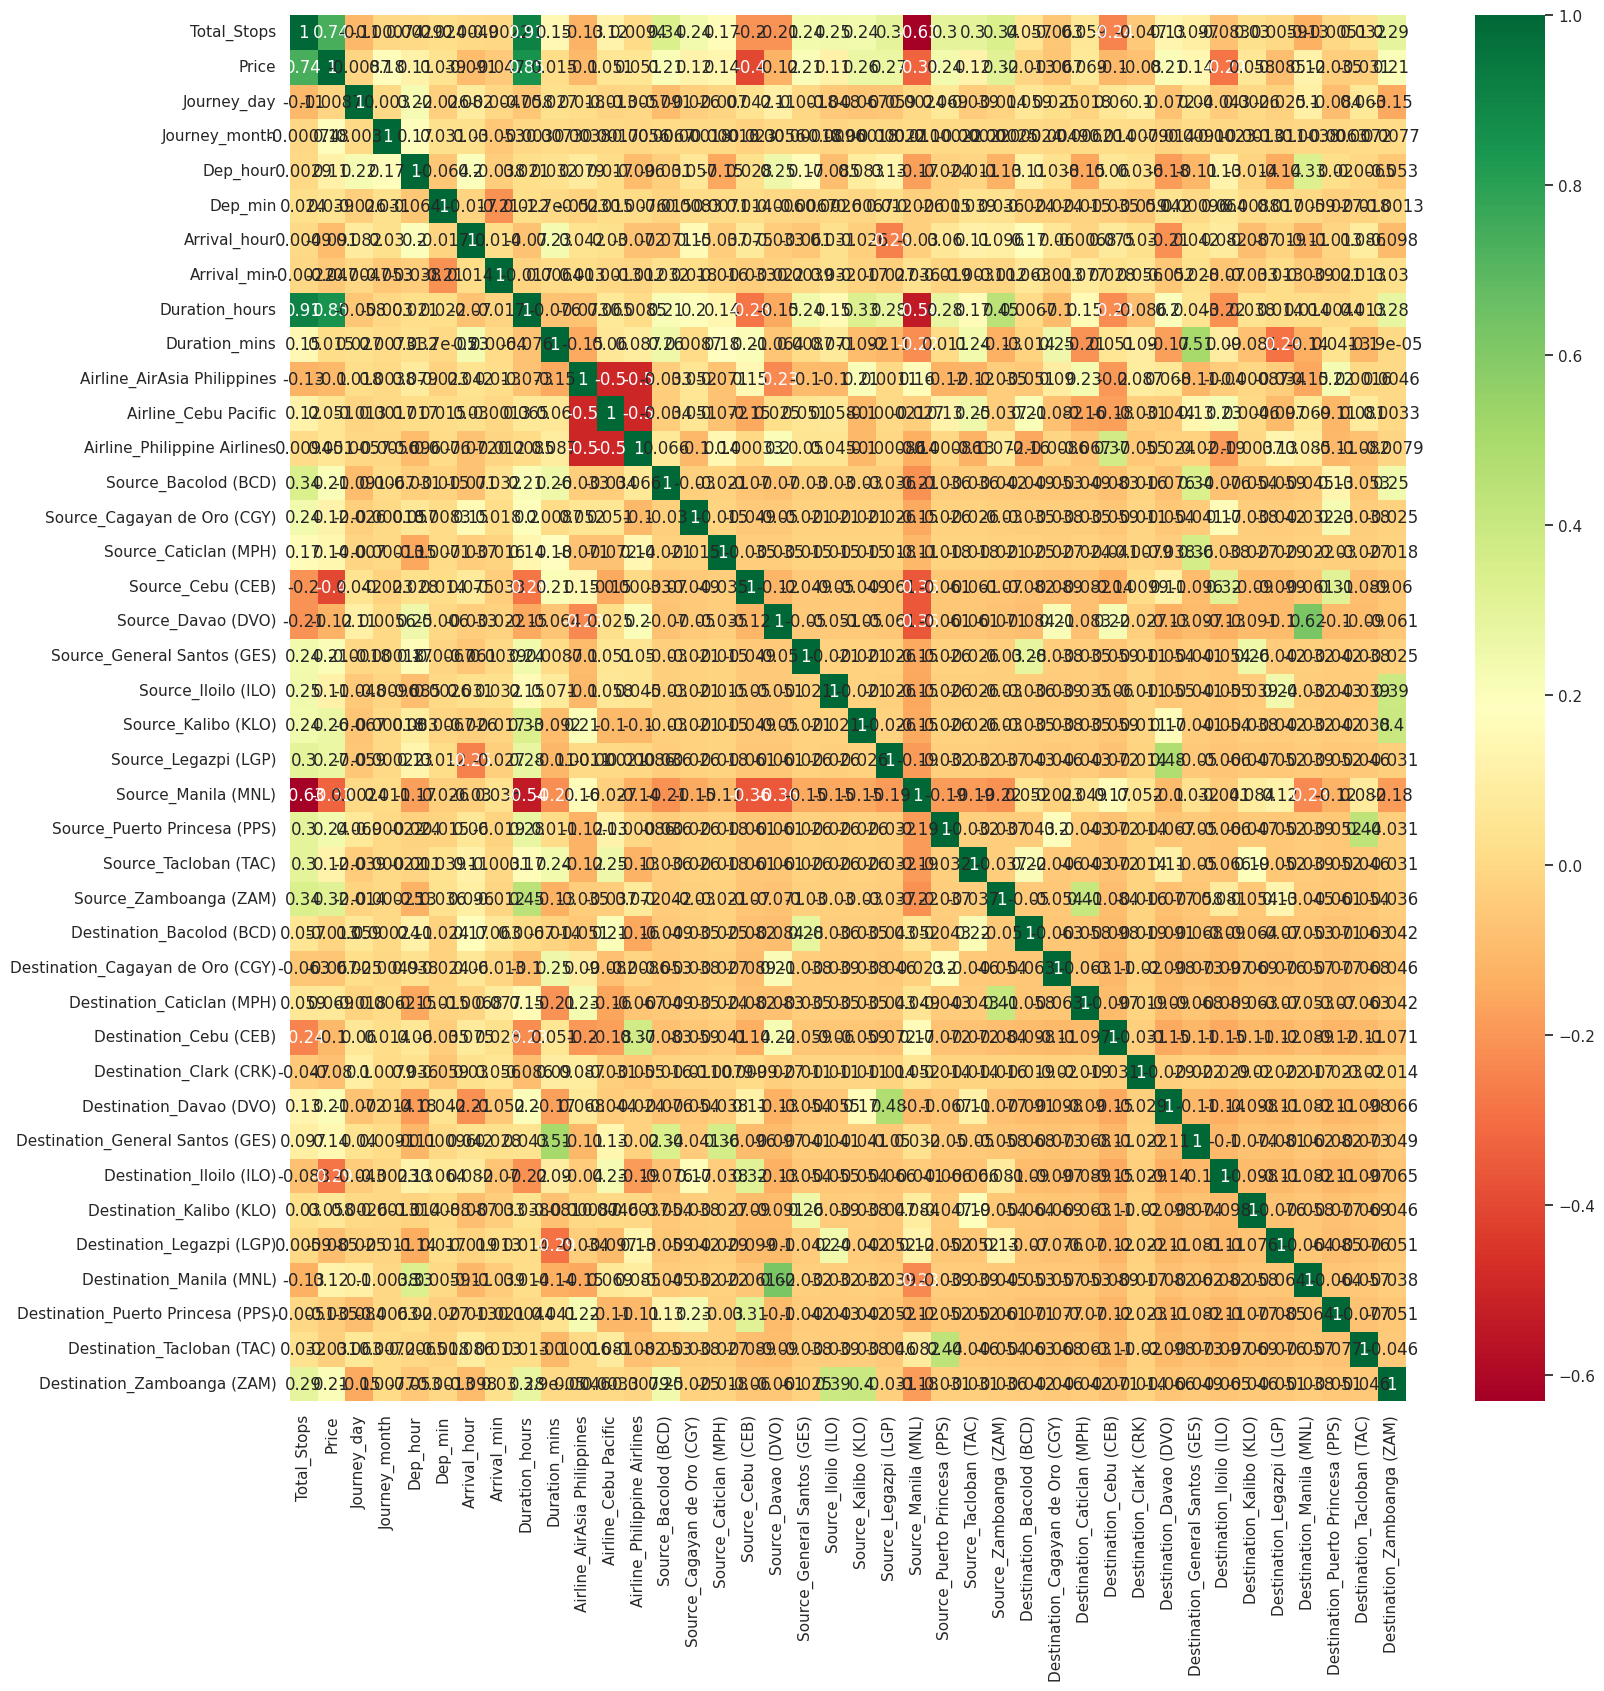

In [469]:
# Finds correlation between Independent and dependent attributes

# Convert 'Price' column to numeric in data_train, coercing errors to NaN and then dropping them
data_train['Price'] = pd.to_numeric(data_train['Price'], errors='coerce')
data_train.dropna(subset=['Price'], inplace=True)

plt.figure(figsize = (18,18))
sns.heatmap(data_train.corr(), annot = True, cmap = "RdYlGn")

plt.show()

In [ ]:
# Important feature using ExtraTreesRegressor

from sklearn.ensemble import ExtraTreesRegressor
selection = ExtraTreesRegressor()
selection.fit(X, y)

ExtraTreesRegressor()

In [ ]:
print(selection.feature_importances_)

[4.36022180e-01 8.13990935e-03 9.27377670e-02 1.45073902e-02
 4.61262229e-03 1.39907368e-02 5.71677141e-03 3.35520923e-01
 2.57360713e-02 1.81461436e-03 4.69885488e-03 4.95650285e-03
 2.37176992e-04 2.29193402e-03 3.36507275e-05 3.76831349e-03
 3.28029997e-04 5.30291317e-05 3.80370752e-04 5.76640705e-05
 1.38288691e-03 1.38767518e-02 2.81496948e-04 8.02246746e-05
 4.01117091e-05 3.46091261e-04 5.83552947e-04 3.74505295e-04
 2.37520505e-03 2.37880324e-04 1.71117860e-03 1.26851646e-03
 2.10565402e-03 1.47424024e-03 1.08283939e-02 1.86487211e-04
 3.30669375e-03 3.10105943e-03 8.34556406e-04]


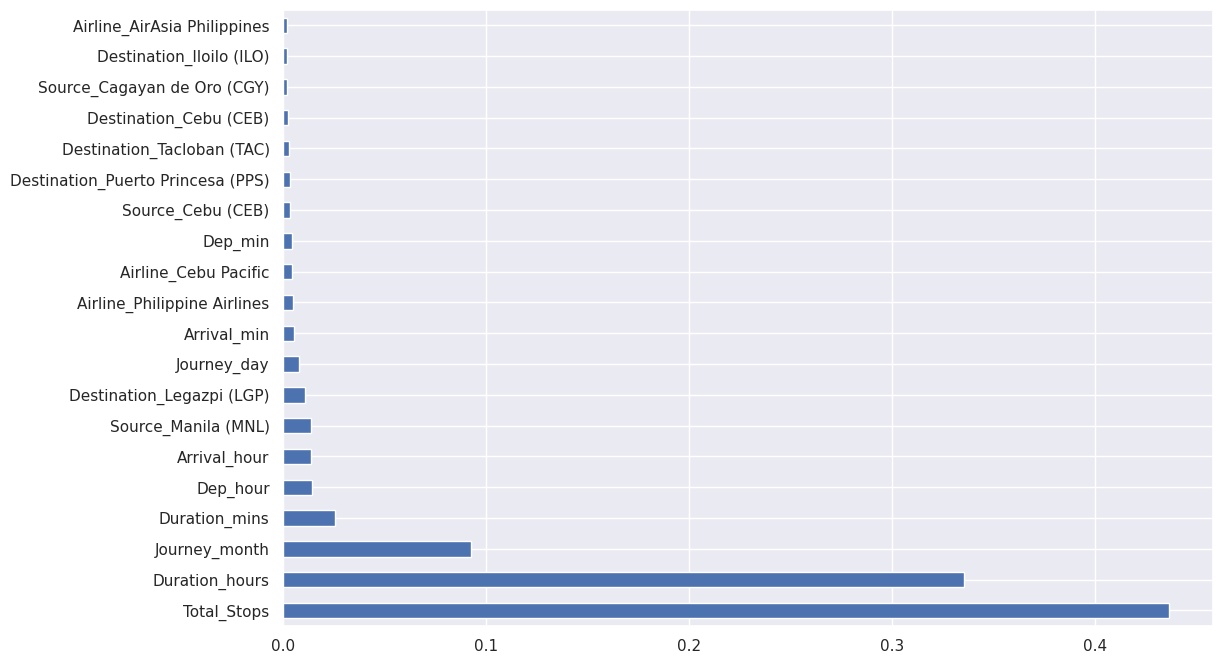

In [ ]:
#plot graph of feature importances for better visualization

plt.figure(figsize = (12,8))
feat_importances = pd.Series(selection.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

In [473]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [474]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Initialize the regressor
reg_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

# Ensure 'Total_Stops' is numeric (int) in both X_train and X_test
X_train['Total_Stops'] = X_train['Total_Stops'].astype(int)
X_test['Total_Stops'] = X_test['Total_Stops'].astype(int)

# Align columns of X_test with X_train after train-test split
# This is crucial if some categories are present in train but not test split, or vice-versa.
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Align columns of data_test with X_train (for future prediction on actual test set)
data_test = data_test.reindex(columns=X_train.columns, fill_value=0)

# Fit the model just like you did with Random Forest
reg_xgb.fit(X_train, y_train)

# Make predictions
y_pred = reg_xgb.predict(X_test)

In [475]:
y_pred = reg_xgb.predict(X_test)

In [ ]:
reg_xgb.score(X_train, y_train)

0.9911500215530396

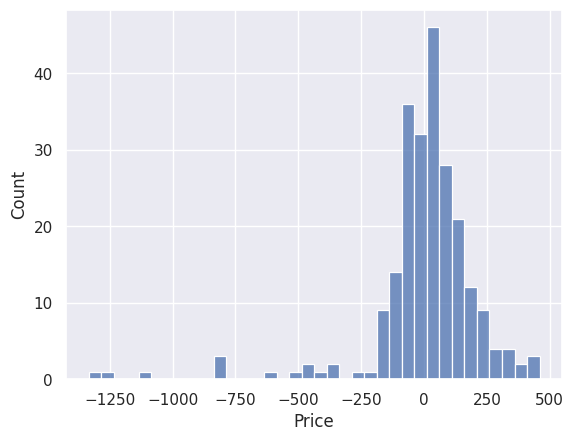

In [ ]:
sns.histplot(y_test-y_pred)
plt.show()

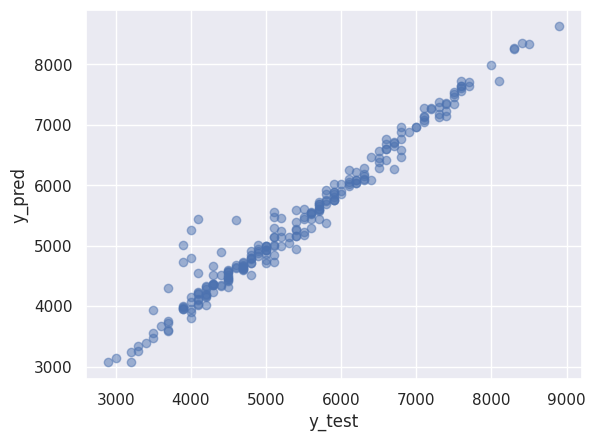

In [ ]:
plt.scatter(y_test, y_pred, alpha = 0.5)
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.show()

In [479]:
from sklearn import metrics

In [ ]:

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 132.93255615234375
MSE: 50711.40234375
RMSE: 225.1919233537251


In [ ]:
# RMSE/(max(DV)-min(DV))

2090.5509/(max(y)-min(y))

0.3318334761904762

In [ ]:
metrics.r2_score(y_test, y_pred)

0.9680936932563782

In [ ]:
import pickle

# 1. Save the model correctly
save_path = '/content/drive/MyDrive/Colab Notebooks/flight_xgb.pkl'

with open(save_path, 'wb') as file:
    pickle.dump(reg_xgb, file)

print("Model saved successfully!")

# 2. Load the model back
with open(save_path, 'rb') as model_file:
    model_xgb = pickle.load(model_file)

# 3. Test prediction
y_prediction = model_xgb.predict(X_test)
print(f"R2 Score: {metrics.r2_score(y_test, y_prediction)}")

Model saved successfully!
R2 Score: 0.9680936932563782
